In [1]:
from codebase.utils_ml import *

In [2]:
features_memmap = np.load('features_extracted_8_sim.npy', mmap_mode='r')

# features_memmap = np.load('data/features_filtered.npy', mmap_mode='r')
old_label_arr = np.array([np.tile(i,3000) for i in np.arange(0,8)]).flatten()

# Define the mapping from class labels (0 to 7) to the new 3-element array format
# where each element in the array represents the number of poles on [bt], [bb], and [tb]
class_to_poles = {
    0: [1, 0, 0],  # 1 pole on [bt]
    1: [0, 1, 0],  # 1 pole on [bb]
    2: [0, 0, 1],  # 1 pole on [tb]
    3: [1, 1, 0],  # 1 pole on [bt] and 1 pole on [bb]
    4: [0, 1, 1],  # 1 pole on [bb] and 1 pole on [tb]
    5: [1, 1, 1],  # 1 pole on each of [bt], [bb], and [tb]
    6: [0, 2, 1],  # 2 poles on [bb] and 1 pole on [tb]
    7: [0, 1, 2]   # 1 pole on [bb] and 2 poles on [tb]
}

new_label_arr = convert_labels(old_label_arr, class_to_poles)

X_train, X_test, y_train, y_test = train_test_split(features_memmap, new_label_arr, test_size=0.1, random_state=42)

In [3]:
# Train Pool for CatBoost (multi-output regression requires separate models per target)
models = []
preds = []

for i in range(y_train.shape[1]):
    train_pool = Pool(X_train, y_train[:, i])
    val_pool = Pool(X_test, y_test[:, i])

    model = CatBoostRegressor(
    iterations=5000,             # Reduce iterations
    loss_function='RMSE',
    random_seed=0,
    verbose=100,
    early_stopping_rounds=10,    # Stop early if no improvement
    depth=3
        )
    model.fit(train_pool, eval_set=val_pool, use_best_model=False)
    models.append(model)

    # Generate predictions with uncertainty
    pred = model.predict(X_test)
    preds.append(pred)  # Mean predictions
    

# Convert lists to arrays for easier manipulation
preds = np.column_stack(preds)

Learning rate set to 0.017979
0:	learn: 0.4792636	test: 0.4735763	best: 0.4735763 (0)	total: 58.5ms	remaining: 4m 52s
100:	learn: 0.2649128	test: 0.2636638	best: 0.2636638 (100)	total: 784ms	remaining: 38s
200:	learn: 0.2305410	test: 0.2308714	best: 0.2308714 (200)	total: 1.48s	remaining: 35.4s
300:	learn: 0.2159974	test: 0.2182992	best: 0.2182992 (300)	total: 2.17s	remaining: 33.8s
400:	learn: 0.2061709	test: 0.2102229	best: 0.2102229 (400)	total: 2.87s	remaining: 32.9s
500:	learn: 0.1985715	test: 0.2039131	best: 0.2039131 (500)	total: 3.6s	remaining: 32.4s
600:	learn: 0.1917170	test: 0.1984717	best: 0.1984717 (600)	total: 4.33s	remaining: 31.7s
700:	learn: 0.1856902	test: 0.1938555	best: 0.1938555 (700)	total: 5.02s	remaining: 30.8s
800:	learn: 0.1806149	test: 0.1900909	best: 0.1900909 (800)	total: 5.72s	remaining: 30s
900:	learn: 0.1758521	test: 0.1866822	best: 0.1866822 (900)	total: 6.43s	remaining: 29.3s
1000:	learn: 0.1715611	test: 0.1836061	best: 0.1836061 (1000)	total: 7.15s	re

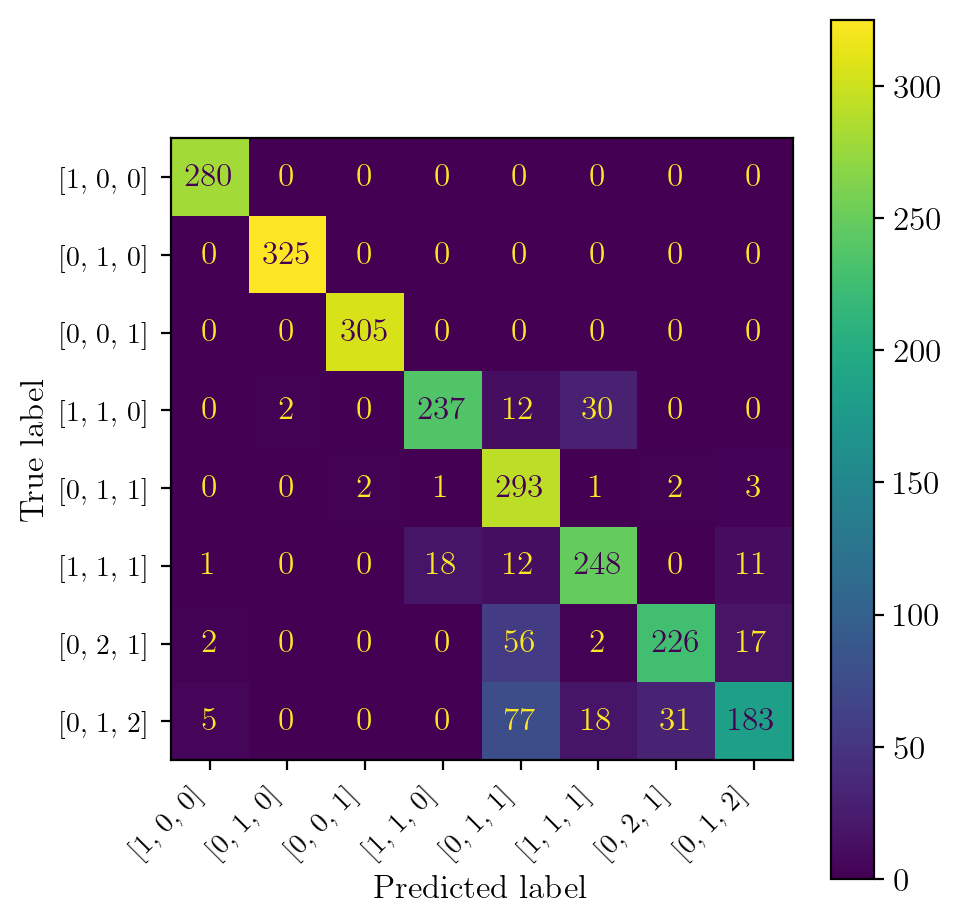

In [4]:
predictions_converted = reconvert_labels(np.abs(np.round(preds)).tolist(), class_to_poles)
mean_predictions = np.round(np.array(predictions_converted))

plot_cm(reconvert_labels(y_test, class_to_poles), mean_predictions, class_to_poles)

(array([ 485.,    0.,    0.,    0.,    0.,  382.,    0., 1721.,    0.,
         412.]),
 array([0. , 0.7, 1.4, 2.1, 2.8, 3.5, 4.2, 4.9, 5.6, 6.3, 7. ]),
 <BarContainer object of 10 artists>)

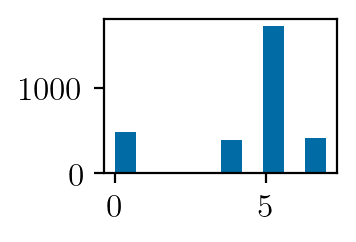

In [5]:
# Train Pool for CatBoost (multi-output regression requires separate models per target)
X_exp = np.load("features_extracted_8_exp.npy")
preds_exp = []

for i in range(y_train.shape[1]):    
    # Generate predictions with uncertainty
    pred = models[i].predict(X_exp)
    preds_exp.append(pred)  # Mean predictions
    
# Convert lists to arrays for easier manipulation
preds_exp = np.column_stack(preds_exp)

fig, ax = plt.subplots(figsize=(1.5,1))
ax.hist(reconvert_labels(np.round(preds_exp), class_to_poles))

# Training Threshold

In [6]:
# preds_train = []
# data_uncertainty_train = []
# knowledge_uncertainty_train = []

# preds_test = []
# data_uncertainty_test = []
# knowledge_uncertainty_test = []

# for i in range(y_train.shape[1]):
#     train_pool = Pool(X_train, y_train[:, i])
#     val_pool = Pool(X_test, y_test[:, i])

#     model = models[i]

#     # Generate predictions with uncertainty
#     pred_train = model.virtual_ensembles_predict(X_train, prediction_type='TotalUncertainty', virtual_ensembles_count=10)
#     preds_train.append(pred_train[:, 0])  # Mean predictions
#     data_uncertainty_train.append(pred_train[:, 2])  # Data uncertainty
#     knowledge_uncertainty_train.append(pred_train[:, 1])  # Knowledge uncertainty

#     pred_test = model.virtual_ensembles_predict(X_test, prediction_type='TotalUncertainty', virtual_ensembles_count=10)
#     preds_test.append(pred_test[:, 0])  # Mean predictions
#     data_uncertainty_test.append(pred_test[:, 2])  # Data uncertainty
#     knowledge_uncertainty_test.append(pred_test[:, 1])  # Knowledge uncertainty

# # Convert lists to arrays for easier manipulation
# preds_train = np.column_stack(preds_train)
# data_uncertainty_train = np.column_stack(data_uncertainty_train)
# knowledge_uncertainty_train = np.column_stack(knowledge_uncertainty_train)

# preds_test = np.column_stack(preds_test)
# data_uncertainty_test = np.column_stack(data_uncertainty_test)
# knowledge_uncertainty_test = np.column_stack(knowledge_uncertainty_test)

In [7]:
# optimized_thresholds = optimize_thresholds(preds_train, y_train, class_to_poles)
# print("Optimized Thresholds:", optimized_thresholds)

In [8]:
# adjusted_preds_train = round_with_thresholds(preds_train, optimized_thresholds, class_to_poles)

# res_ = np.sum(np.sum(np.round(preds_train) == y_train, axis=1) == 3)/y_train.shape[0]
# print(f"Test Accuracy Baselie: {np.mean(res_):.4f}")

# res_ = np.sum(np.sum(adjusted_preds_train == y_train, axis=1) == 3)/y_train.shape[0]
# print(f"Test Accuracy Improved: {np.mean(res_):.4f}")

In [9]:
# adjusted_preds = round_with_thresholds(preds, optimized_thresholds, class_to_poles)

# res_ = np.sum(np.sum(np.round(preds) == y_test, axis=1) == 3)/y_test.shape[0]
# print(f"Test Accuracy Baselie: {np.mean(res_):.4f}")

# res_ = np.sum(np.sum(adjusted_preds == y_test, axis=1) == 3)/y_test.shape[0]
# print(f"Test Accuracy: {np.mean(res_):.4f}")

In [10]:
# Test Accuracy Baselie: 0.9281
# Test Accuracy Improved: 0.9326

# Test Accuracy Baselie: 0.8554
# Test Accuracy Improved: 0.8638

# Removing

In [11]:
# # Sort the data by uncertainty for each target
# mse_changes = []
# percent_removed = []

# for i in range(y_train.shape[1]):
#     sorted_indices = np.argsort(data_uncertainty[:, i])[::-1] 
#     sorted_uncertainties = data_uncertainty[sorted_indices, i]
#     sorted_true = y_test[sorted_indices, i]
#     sorted_preds = preds[sorted_indices, i]

#     # Calculate the MSE after removing samples with the highest uncertainty
#     acc_list = []
#     percent_list = []
#     total_samples = len(sorted_uncertainties)

#     for remove_percent in range(0, 101, 5):  # Remove in 5% increments
#         num_remove = int(total_samples * (remove_percent / 100))
#         remaining_true = sorted_true[num_remove:]
#         remaining_preds = sorted_preds[num_remove:]

#         # mse = np.mean((remaining_true - remaining_preds) ** 2)  # Calculate MSE
#         acc = np.sum(remaining_true == np.round(remaining_preds)) /remaining_preds.shape[0]
#         acc_list.append(acc)
#         percent_list.append(remove_percent)
        

#     mse_changes.append(acc_list)
#     percent_removed.append(percent_list)

# # Plot the results
# # plt.figure(figsize=(15, 5))
# fig, axs = plt.subplots(1,figsize=(3.54331, 3.54331*0.75))

# for i in range(y_train.shape[1]):
#     axs.plot(percent_removed[i], mse_changes[i],"-o", label=f"Pole Idx {i+1}")
# axs.set_xlabel("Percentage of Rejected Samples")
# axs.set_ylabel("Accuracy")
# # axs.set_title("Impact of Removing High-Uncertainty Samples on Acc")
# axs.legend()
# axs.set_xticks([0, 20, 40, 60, 80, 100])
# axs.set_xticklabels([f"{int(p)}\%" for p in [0, 20, 40, 60, 80, 100]])
# axs.grid(True)
# fig.tight_layout()
# # fig.show()

# Hist

In [12]:
# # Number of classes
# num_classes = 8
# custom_labels = [str(class_to_poles[i]) for i in range(len(class_to_poles))]
# # Initialize an array to store accuracies for each class across folds
# class_accuracies= []
# class_uncer = []


# for cls in range(num_classes):
#     # Mask for the current class
    
#     class_mask = (reconvert_labels(y_test, class_to_poles) == cls)
#     # Calculate accuracy for the current fold and class
#     # /np.sum(np.ones_like(y_test[:,0]))
#     class_accuracy = np.sum(np.sum(adjusted_preds[class_mask]==y_test[class_mask],axis=1) == 3) / np.sum(class_mask)
#     class_accuracies.append(class_accuracy)

#     class_u = np.mean(data_uncertainty_test[class_mask])
#     class_uncer.append(class_u)

# class_accuracies = np.array(class_accuracies)
# class_uncer = np.array(class_uncer)
# # Bar plot with error bars
# sorted_indices = np.argsort(class_accuracies)[::-1]
# sorted_means = class_accuracies[sorted_indices]
# sorted_stds = class_uncer[sorted_indices]
# sorted_labels = [str(class_to_poles[i]) for i in sorted_indices]

# # Plotting
# fig, ax = plt.subplots(figsize=(3.54331, 3.54331*0.75))
# ax.bar(range(num_classes), sorted_means, yerr=sorted_stds, capsize=5)
# ax.set_ylabel('Accuracy')

# ax.set_xticks(np.arange(len(sorted_labels)))
# ax.set_xticklabels(sorted_labels, rotation=45, ha='right', fontsize=10)
# ax.set_ylim(0,1)
# # Adjust layout and show the plot
# plt.tight_layout()
# plt.show()

In [13]:
# custom_labels = [str(class_to_poles[i]) for i in range(len(class_to_poles))]

# # Compute the confusion matrix
# predictions = reconvert_labels(np.abs(np.round(preds)).tolist(), class_to_poles)
# cm = confusion_matrix(reconvert_labels(y_test, class_to_poles), predictions, labels=np.arange(len(class_to_poles)))

# # Plot the confusion matrix
# disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(len(class_to_poles)))
# fig, ax = plt.subplots(figsize=(5, 5))  # Adjust figure size if needed
# disp.plot(ax=ax)

# # Update x and y axis tick labels with the custom labels
# ax.set_xticks(np.arange(len(custom_labels)))
# ax.set_yticks(np.arange(len(custom_labels)))
# ax.set_xticklabels(custom_labels, rotation=45, ha='right', fontsize=10)
# ax.set_yticklabels(custom_labels, fontsize=10)

# # Adjust layout for readability
# plt.tight_layout()
# plt.show()